<div style="text-align: right;">
  <img src="Logo_UNSAM.png" width="250">
</div>

Analisis y Procesamiento de Señales

# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.

## Estudiante: Mercedes López Gil Dillon

En este trabajo, vamos a trabajar lo que es y el efecto que tiene el desparramo espectral (leakage), y cuál es el efecto y las ventajas que tiene hacerle zero-padding a una señal.

## Ejercicio a

En este ejercicio crearemos una señal senoidal de frecuencia f0=k0.Δf, con potencia normalizada.

Los valores de k0 serán los siguientes:
- N/4
- N/4 + 0.25
- N/4 + 0.5

El objetivo es poder generar los respectivos espectros y discutir el efecto de leakage en base a sus resultados.


***¿Qué es el leakage?***

Antes de comenzar con este ejercicio, es importante entender lo que es el desparramo espectral (leakage) para poder preveer e interpretar de manera correcta los resultados.

Al momento de calcular una DFT, esta se cualcula multiplicándola por una ventana de algún tipo. Si no se elije ninguna ventana en particular (como en nuestro caso), la DFT se calculará con un pulso rectangular de duración N y altura 1. Por lo general, no notamos la presencia de esta ventana rectangular al observar el espectro de mi señal, y esto se debe a que mi espectro es una SINC periódica con altura del lóbulo principal igual a la amplitud de la senoidal localizada en f0 * resolución espectral, y ancho de los lóbulos igual a mi resolución espectral. Esto resulta en que, al tomar las muestras, todas estas coinciden con los cruces por cero de la SINC, excepto por la muestra donde está el lóbulo principal (que coincide con mi delta).

A su vez, al momento de calcular una DFT, existe una periodicidad implícita, donde se asume que el último valor de la señal coincide con el primero.

Entonces, el fenómeno de desparramo espectral ocurre cuando esta periodicidad implicita no se cumple, y no se logra completar el último período, resultando en que al asumir esta periodicidad, se produzca una discontinuidad.

Al verlo en el espectro, esto implica que hay un corrimiento de las muestras tomadas con respecto a la SINC obtenida en el resultado, lo que implica que las muestras dejan de coincidir con los ceros de esta para pasar a tener otro valor y el valor máximo deja de caer sobre el máximo del lóbulo principal para pasar a caer cerca de este.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#%%
'Defino mis funciones'

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

Definimos los parametros de la señal

In [3]:
A = np.sqrt(2)
dc = 0
fs = 1000
Ts= 1/fs
fase = 0
N = 100
Ps = (A**2)/ 2 

Comenzamos por generar la señal y el espectro de la señal con k=N/4, con la cual f0= 250Hz y la energía del espectro (la delta) caería en el bin 250.

In [4]:
k = [N/4, N/4 + 1/2, N/4 + 1/4] #generamos acá los tres valores de k para poder deter inar facilmente los tres valores posibles de f0
f0 = k[0] * (fs/N)

tt, xx = mi_funcion_sen(A, dc, f0, fase, N, fs)

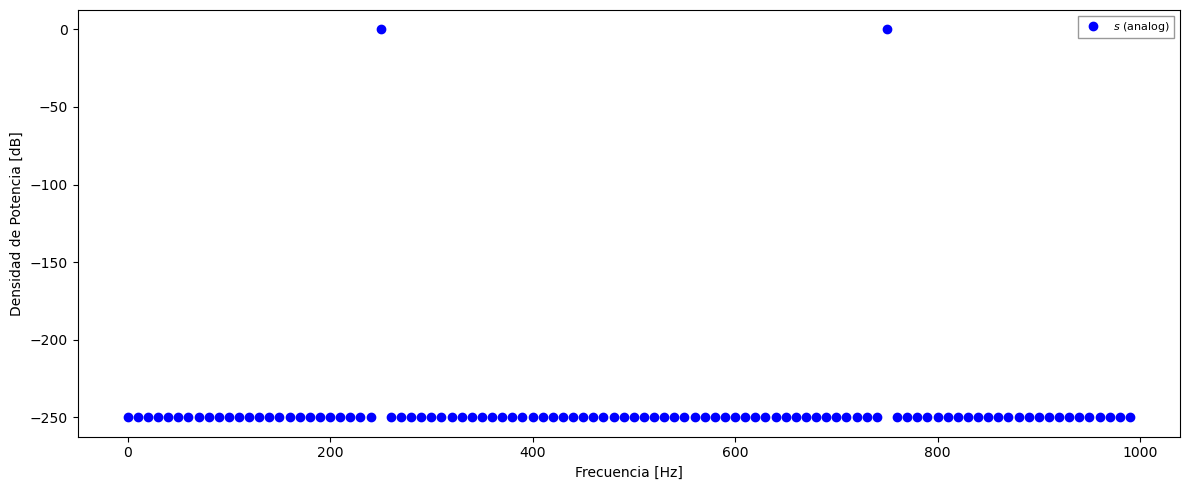

In [5]:
EspectroXX = np.fft.fft(xx)/N
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 #cambaido


xx_db = 10 * np.log10(Mod_EspXX + 1e-25)


Frec = np.arange(0, fs, fs/N)


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec, xx_db, color='blue', linewidth=1.8, linestyle='none', marker = 'o',
        label=r'$s$ (analog)')

ax.set_title("")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Densidad de Potencia [dB]")
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

Notamos que, como habíamos predicho, este espectro no tiene ningún tipo de leakage, siendo el resultado dos deltas (en 250 y 750 Hz como lo esperado).

Ahora haremos lo mismo, pero con un pequeño corrimiento de f0 con k=N/4+1/4

In [6]:
f0 = k[2] * (fs/N)

tt, xx = mi_funcion_sen(A, dc, f0, fase, N, fs)

El cambio en amplitud que se observa se debe a que al estar f0 levemente corrido de N/4 hay momentos en los que la muestra tomada no es del máximo de ese período, resultando en un efecto visual en el que parece que la amplitud varía.

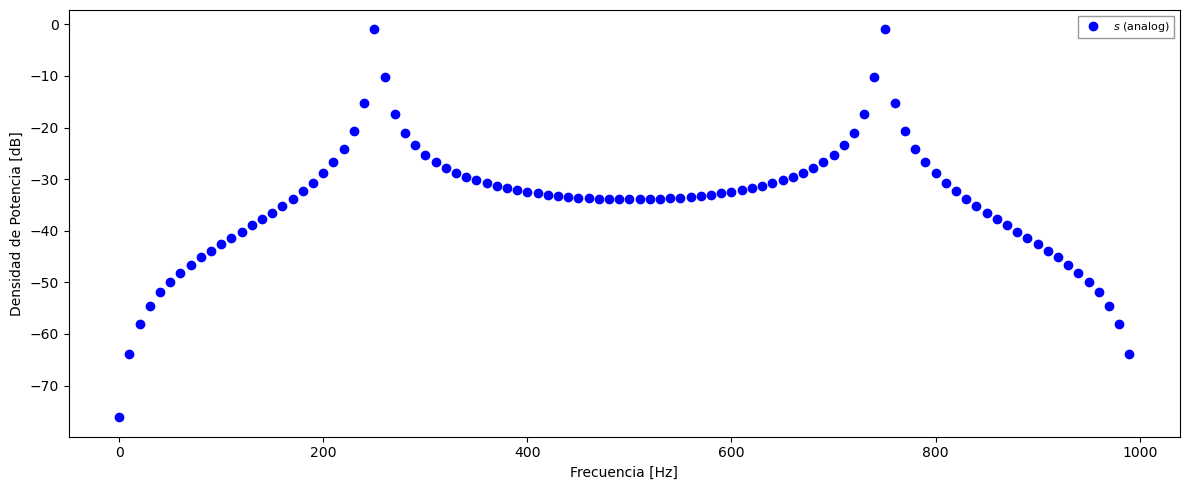

In [7]:
EspectroXX_k2 = np.fft.fft(xx)/N
Mod_EspXX_k2 = 2 * (np.abs(EspectroXX_k2))**2 #cambaido


xx_db = 10 * np.log10(Mod_EspXX_k2 + 1e-25)


Frec = np.arange(0, fs, fs/N)


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec, xx_db, color='blue', linewidth=1.8, linestyle='none', marker = 'o',
        label=r'$s$ (analog)')

ax.set_title("")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Densidad de Potencia [dB]")
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

En este espectro podemos observar como ya los resultados no son los de una delta limpia, sino que es un desparramo a lo largo de todo el espectro, con un maximo alrededor de los bins más cercanos (f= 250 y 750 Hz).

Realizamos por ultimo el gráfico con el mayor corrimiento de f0 con su bin más cercano (con k= N/4 + 1/2).

In [8]:
f0 = k[1] * (fs/N)

tt, xx = mi_funcion_sen(A, dc, f0, fase, N, fs)

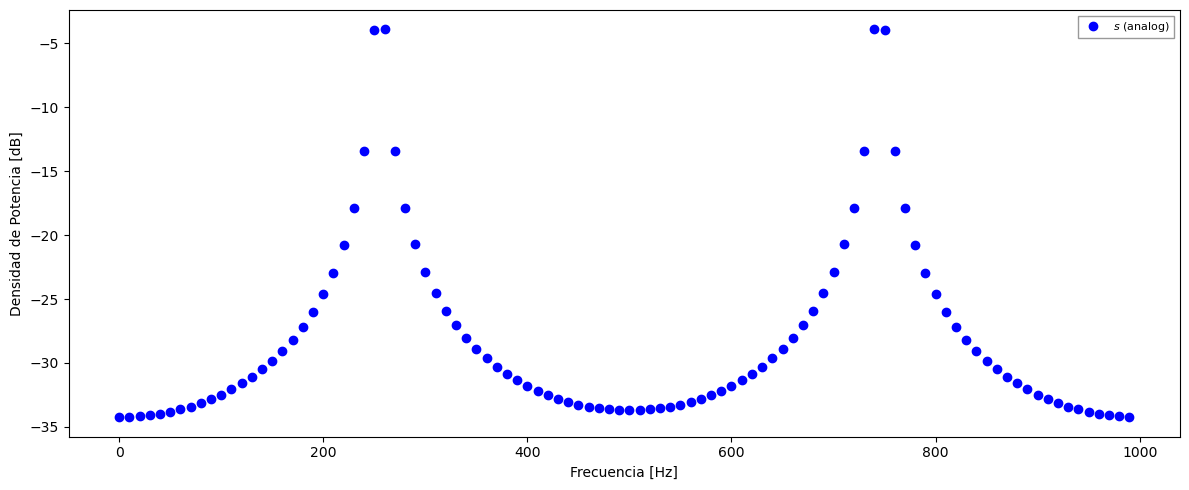

In [9]:
EspectroXX_k1 = np.fft.fft(xx)/N
Mod_EspXX_k1 = 2 * (np.abs(EspectroXX_k1))**2 #cambaido


xx_db = 10 * np.log10(Mod_EspXX_k1 + 1e-25)


Frec = np.arange(0, fs, fs/N)


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(Frec, xx_db, color='blue', linewidth=1.8, linestyle='none', marker = 'o',
        label=r'$s$ (analog)')

ax.set_title("")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Densidad de Potencia [dB]")
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=8)

plt.tight_layout()
plt.show()

El resultado se parece en parte al resultado anterior, sin embargo tiene algunas pequeñas diferencias que podemos notar.

Los máximos de este espectro se encuentran repartidos en dos bins (en el caso de la primer delta en los bins 250 y 251, y en el caso de la segunda en los bins 749 y 750), lo que se debe a que el f0 usado en este caso está exactamente en 250.5, a igual distancia de f=250Hz y f=251Hz. 

Otra cosa a notar es como el ancho del manchado espectral es mayor, generando incluso que la energía mínima que se encuentra en un bin sea de alrededor de -35dB (recordemos que en nuestro primer espectro, sin leakage, ronsaba los -250dB).

***Conclusion***

De este primer ejercicio, pudimos observar como, a medida que la energía del espectro se aleja más de un bin donde pueda caer esta información, más desparramo espectral (leakage) tendré, pudiendo ver así la importancia de elegir una frecuencia de mi señal acorde con mi resolución espectral.

## Ejercicio b

El objetivo de este ejercicio es calcular y verificar la potencia unitaria de las distintas señales ya calculadas.

In [10]:
#Uso la identidad de Parseval

P0 = np.sum(np.abs(EspectroXX**2))
P1 = np.sum(np.abs(EspectroXX_k1**2))
P2 = np.sum(np.abs(EspectroXX_k2**2))

In [11]:
print('La potencia del espectro con f0= 250Hz es', P0)
print('La potencia del espectro con f0= 250.5Hz es', P1)
print('La potencia del espectro con f0= 250.25Hz es', P2)

La potencia del espectro con f0= 250Hz es 1.0000000000000002
La potencia del espectro con f0= 250.5Hz es 0.9999999999999996
La potencia del espectro con f0= 250.25Hz es 0.9900000000000002


Podemos observar que la potencia en los tres casos ronda 1 (potencia unitaria como esperábamos). Sin embargo, en el caso de f0=250.25Hz podemos notar como la potencia es menor que en los otros casos. 

Esto se debe a que en el caso de f0=250.25Hz la señal no logra completar el ciclo (quedando un cuarto de un ciclo completo). Al momento de calcular la potencia se hace un promedio de la potencia en cada ciclo, y al este estar incompleto resulta en tirar para abajo el promedio total de la potencia de la señal.

¿Por qué no ocurre esto mismo con la señal de f0=250.5? Esto se debe a la definicion misma de potencia y a la forma que tiene una señal senoidal. Al momento de calcular la potencia de la señal, se calcula elevando al cuadrado el espectro. Con f0=250.5Hz, mi ultimo ciclo queda exactamente por la mitad, y al elevar este al cuadrado, el resultado termina siendo el mismo si estoy a mitad de ciclo o con un ciclo completo. Es por esto que el resultado de la potencia en el caso de f0= 250.5Hz no disminuye.

## Ejercicio c

El objetivo para este último ejercicio es repetir el experimento mediante la técnica de zero padding, agregando un vector de 9*N ceros para poder observar y discutir los resultados.

¿Qué es el zero-padding?

Este consiste en agregar ceros al final de mi señal, con el objetivo de aumentar mi número de N muestras usando la misma información, lo que genera que mi resolución espectral (fs/N) sea más chica, eniendo entonces más bins de información.

Empezamos graficando el espectro y el padding de k= N/4

In [12]:
f0 = k[0] * (fs/N)

tamaño_padding = 9
N_pad = tamaño_padding * N + N

tt, xx = mi_funcion_sen(A, dc, f0, fase, N, fs)
zz = np.zeros(tamaño_padding * len(xx))
xx_padding = np.concatenate((xx, zz), axis=None)
tt_padding = np.arange(0, len(xx_padding)) * Ts

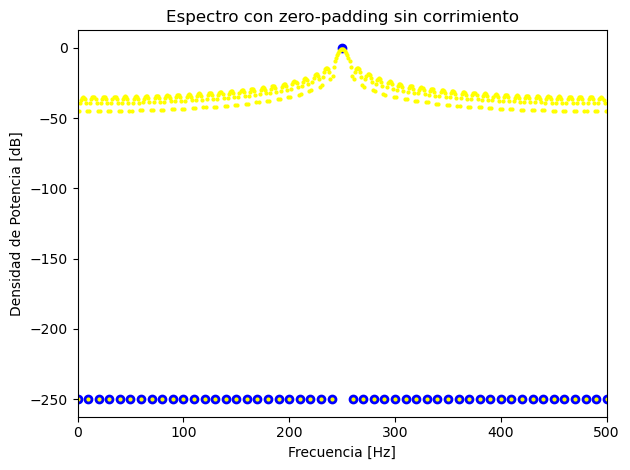

In [16]:
EspectroXX = np.fft.fft(xx)/N
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 #cambaido

xx_db = 10 * np.log10(Mod_EspXX + 1e-25)

EspectroXX_pad = tamaño_padding * np.fft.fft(xx_padding)/N_pad
Mod_EspXX_pad = 2 * (np.abs(EspectroXX_pad))**2 #cambaido

#Potencia
P = np.sum(Mod_EspXX_pad**2)

xx_db_pad = 10 * np.log10(Mod_EspXX_pad + 1e-25)

Frec = np.arange(0, fs, fs/N)
Frec_pad = np.arange(0, fs, fs/(N_pad))

plt.plot(Frec, xx_db, 'o', color='blue', label='Original')
plt.plot(Frec_pad, xx_db_pad, 'o', markersize=2, linewidth=1, color='yellow', label='Zero Padding')
plt.xlim(0, 500)
plt.title("Espectro con zero-padding sin corrimiento")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.tight_layout()
plt.show()

Para que se logre ver el comportamiento le hago zoom al lóbilo principal.

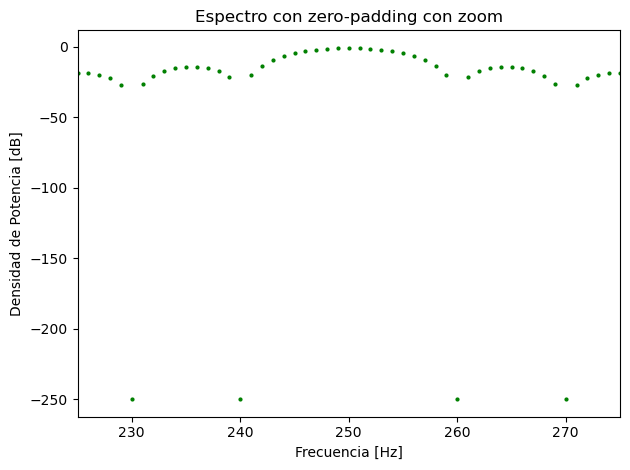

In [17]:
plt.plot(Frec_pad, xx_db_pad, 'o', markersize=2, linewidth=1, color='green', label='Zero Padding')
plt.xlim(225, 275)
plt.title("Espectro con zero-padding con zoom")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.tight_layout()
plt.show()

Seguimos graficando esto mismo con k= N/4 + 1/2 (f0= 250.5Hz).

In [18]:
f0 = k[1] * (fs/N)

tamaño_padding = 9
N_pad = tamaño_padding * N + N

tt, xx = mi_funcion_sen(A, dc, f0, fase, N, fs)
zz = np.zeros(tamaño_padding * len(xx))
xx_padding = np.concatenate((xx, zz), axis=None)
tt_padding = np.arange(0, len(xx_padding)) * Ts

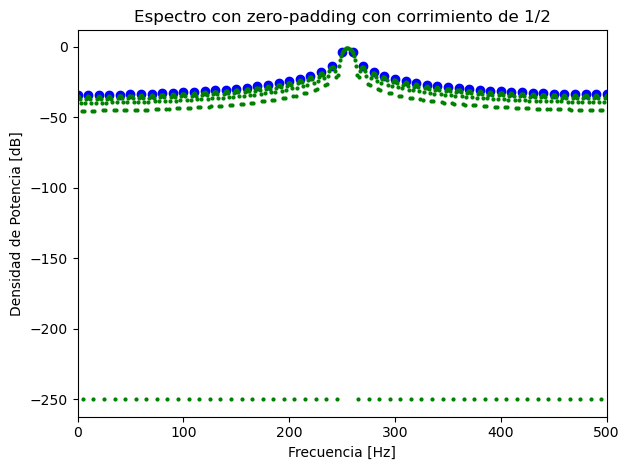

In [19]:
EspectroXX = np.fft.fft(xx)/N
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 #cambaido

xx_db = 10 * np.log10(Mod_EspXX + 1e-25)

EspectroXX_pad = tamaño_padding * np.fft.fft(xx_padding)/N_pad
Mod_EspXX_pad = 2 * (np.abs(EspectroXX_pad))**2 #cambaido

#Potencia
P = np.sum(Mod_EspXX_pad**2)

xx_db_pad = 10 * np.log10(Mod_EspXX_pad + 1e-25)

Frec = np.arange(0, fs, fs/N)
Frec_pad = np.arange(0, fs, fs/(N_pad))

plt.plot(Frec, xx_db, 'o', color='blue', label='Original')
plt.plot(Frec_pad, xx_db_pad, 'o', markersize=2, linewidth=1, color='green', label='Zero Padding')
plt.xlim(0, 500)
plt.title("Espectro con zero-padding con corrimiento de 1/2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.tight_layout()
plt.show()

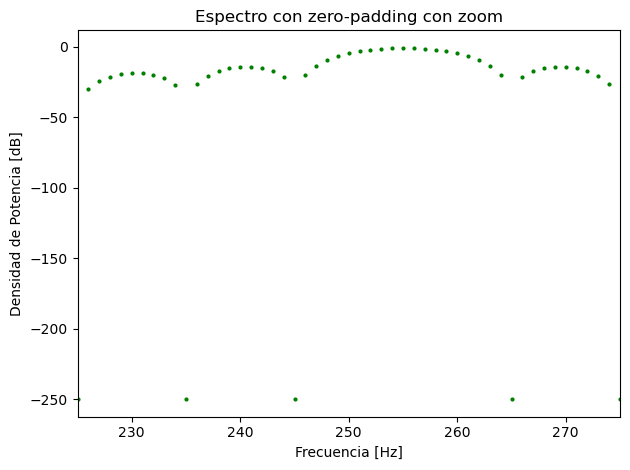

In [20]:
plt.plot(Frec_pad, xx_db_pad, 'o', markersize=2, linewidth=1, color='green', label='Zero Padding')
plt.xlim(225, 275)
plt.title("Espectro con zero-padding con zoom")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.tight_layout()
plt.show()

Por ultimo, graficamos lo mismo con k= N/4 + 1/4 (f0= 250.25Hz).

In [21]:
f0 = k[2] * (fs/N)

tamaño_padding = 9
N_pad = tamaño_padding * N + N

tt, xx = mi_funcion_sen(A, dc, f0, fase, N, fs)
zz = np.zeros(tamaño_padding * len(xx))
xx_padding = np.concatenate((xx, zz), axis=None)
tt_padding = np.arange(0, len(xx_padding)) * Ts

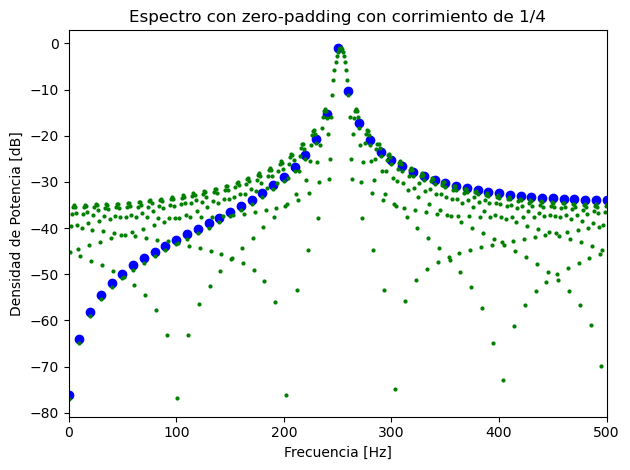

In [22]:
EspectroXX = np.fft.fft(xx)/N
Mod_EspXX = 2 * (np.abs(EspectroXX))**2 #cambaido

xx_db = 10 * np.log10(Mod_EspXX + 1e-25)

EspectroXX_pad = tamaño_padding * np.fft.fft(xx_padding)/N_pad
Mod_EspXX_pad = 2 * (np.abs(EspectroXX_pad))**2 #cambaido

#Potencia
P = np.sum(Mod_EspXX_pad**2)

xx_db_pad = 10 * np.log10(Mod_EspXX_pad + 1e-25)

Frec = np.arange(0, fs, fs/N)
Frec_pad = np.arange(0, fs, fs/(N_pad))

plt.plot(Frec, xx_db, 'o', color='blue', label='Original')
plt.plot(Frec_pad, xx_db_pad, 'o', markersize=2, linewidth=1, color='green', label='Zero Padding')
plt.xlim(0, 500)
plt.title("Espectro con zero-padding con corrimiento de 1/4")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.tight_layout()
plt.show()

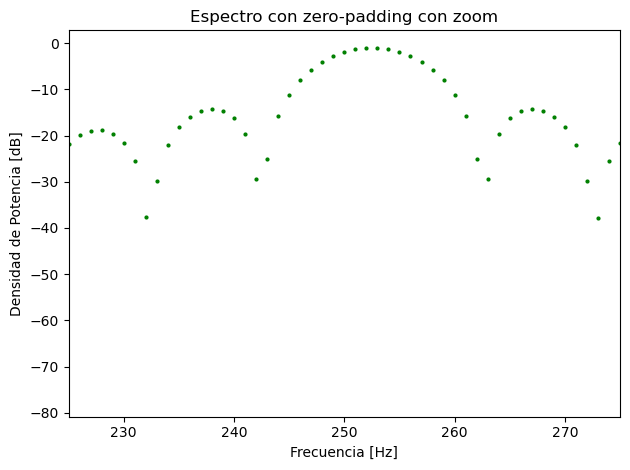

In [23]:
plt.plot(Frec_pad, xx_db_pad, 'o', markersize=2, linewidth=1, color='green', label='Zero Padding')
plt.xlim(225, 275)
plt.title("Espectro con zero-padding con zoom")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.tight_layout()
plt.show()

***Conclusion***

Al hacer zero-padding, pudimos ver de manera clara lo que ya se mencionó anteriormente con respecto al verdadero aspecto de una DFT. 

En el caso de la señal sin leakage (f0= 250Hz) vemos de manera clara el comportamiento de la SINC en las muestras que antes no podíamos ver.

En el caso de la segunda señal (f0= 250.5Hz), vemos este mismo comportamiento de la SINC corrido levemente, lo cual es esperado en base a lo ya hablado anteriormente.

En el tercer espectro observado (f0= 250.25Hz), sin embargo, vemos como este está considerablemente más desordenado que los dos espectros vistos anterioremnte. Esto se debe a que esta señal completó unicamente un cuarto del ciclo esperado, lo que genera una discontinuidad asimétrica, que en el espectro se observa como un gran desorden visual en el comportamiento de la SINC.


Otra cosa que podemos observar de hacer zero-padding, es que este no ayudó en cuanto al desparramo espectral que hay en cada señal. Al disminuir el paso de mi resolución espectral, simplemente logro observar de manera más clara el comportamiento del espectro y el por qué de mis resultados, sin cambiar no obstante los resultados mismos.

Además, pudimos corroborar lo que mencionamos al inicio del trabajo en cuanto al derrame espectral. Vimos que cuando el período logra completarse (en este trabajo usamos el ejemplo de cuando k= N/4) el espectro logra verse tal como esperaríamos para el espectro de una senoidal, que sería una delta. En el momento en que nos alejamos de este punto (vease los casos con k=N/4+1/4 y k= N/4+1/2) y la señal no logra completar su último período, vemos que esto se traduce en el espectro como un desparramo , donde el espectro que antes era una delta pasa a tener energía a lo largo de todos los bins. Notamos también, que al más alejarse de un bin este desparramo es mayor, como se puede contemplar al comparar los casos de k=N/4+1/2 (más lejano de un bin) y k=N/4+1/4 (más cercano a un bin).